# 01 · Exploratory Data Analysis — LineWise DAMM
**Objetivo**: Entender la estructura, calidad y patrones de los datos históricos 2025
de las líneas 14, 17 y 19 de latas de El Prat, y del plan de la semana de test (18-24 mayo 2026).

**Granularidad de análisis**: semanal (ISO week).

## 0 · Modelo de datos operativo: OF/MES como nexo

Este notebook sigue la arquitectura de datos de planta: la OF/MES es el nexo entre cambios, OEE, volumen y tiempos. La lectura operativa clave es que un cambio no vive aislado: para clasificarlo y medir su efecto hay que revisar la OF anterior en la misma linea y ventana temporal.

```mermaid
flowchart LR
    CF["Cambio formato"] -.-> TCT["Tiempo cambio teorico"]
    ML["Mantenimiento y limpiezas"] -.-> TCT
    TCT <--> OF["MES / OF (nexo)"]
    CAM["Cambios"] -.-> OF
    CAM --> TC["Tipo de cambio"]
    TC --> PREV["Revisar OF anterior"]
    OF -.-> OEE["OEE"]
    OF -.-> T["Tiempo"]
    OF -.-> V["Volumen"]
    OEE --> CYN["Cambio si/no"]
    OEE --> KPI["%OEE / %Rendimiento"]
    V --> V2["HL / UDS / OEE"]
    T --> T2["H Tot / Par Tot / PNP / Limpieza / Idle / %Disp / %Calidad / %Rend"]
```

Formulas usadas como control semantico:

- `OEE = Disponibilidad x Rendimiento x Calidad`
- `Disponibilidad = Tiempo funcionamiento / Tiempo planificado`
- `Rendimiento = (Tiempo ciclo ideal x Produccion total) / Tiempo funcionamiento`
- `Calidad = Produccion buena / Produccion total`
- `Tiempo cambio = H Tot - (PNP + Limpieza + Idle)`; `Idle` se separa para no imputarlo automaticamente al OEE.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from analisis_postmorten.data_loaders import load_all_operations, load_diario_hl

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

DATA_DIR = Path('../OPERACIONS')
print("Data dir exists:", DATA_DIR.exists())
print("Archivos disponibles:")
for f in sorted(DATA_DIR.glob('*.xlsx')):
    print(f'  {f.name}')

Data dir exists: True
Archivos disponibles:
  Cambios 14_17_19_ 2025.xlsx
  Diario Hl_Planif.xlsx
  Mantenimiento 14_17_19_ 2025.xlsx
  OEE 14_17_19_ 2025.xlsx
  Planificado - producciones 14 - 17 - 19.xlsx
  Produccion_L14,17,19_18-22.xlsx
  Tabla CF Prat 2026_14_17_19.xlsx
  Tiempo 14_17_19_ 2025.xlsx
  Volumen 14_17_19_ 2025.xlsx
  data - 2026-05-18T181640.542.xlsx


## 1 · Carga y normalización de datos

In [2]:
dfs = load_all_operations(DATA_DIR)
df_oee  = dfs['oee']
df_cam  = dfs['cam']
df_mant = dfs['mant']
df_tiem = dfs['tiem']
df_vol  = dfs['vol']

print(f"OEE:          {df_oee.shape}  | {df_oee['fecha'].min().date()} -> {df_oee['fecha'].max().date()}")
print(f"Cambios:      {df_cam.shape}")
print(f"Mantenimiento:{df_mant.shape}")
print(f"Tiempo:       {df_tiem.shape}")
print(f"Volumen:      {df_vol.shape}")

# Verificacion rapida: OF/MES como nexo disponible en todas las tablas principales.
for name, df in {'OEE': df_oee, 'Cambios': df_cam, 'Mantenimiento': df_mant, 'Tiempo': df_tiem, 'Volumen': df_vol}.items():
    assert 'of' in df.columns, f"{name} no tiene columna OF normalizada"

print(f"\nTren values OEE: {sorted(df_oee['tren'].unique())}")
print(f"OEE L14: {len(df_oee[df_oee['tren']=='14'])} filas | "
      f"L17: {len(df_oee[df_oee['tren']=='17'])} | "
      f"L19: {len(df_oee[df_oee['tren']=='19'])}")

OEE:          (2141, 43)  | 2025-01-02 -> 2025-12-31
Cambios:      (2181, 22)
Mantenimiento:(2142, 23)
Tiempo:       (2143, 33)
Volumen:      (2143, 19)

Tren values OEE: ['14', '17', '19']
OEE L14: 425 filas | L17: 930 | L19: 786


## 2 · Calidad de datos

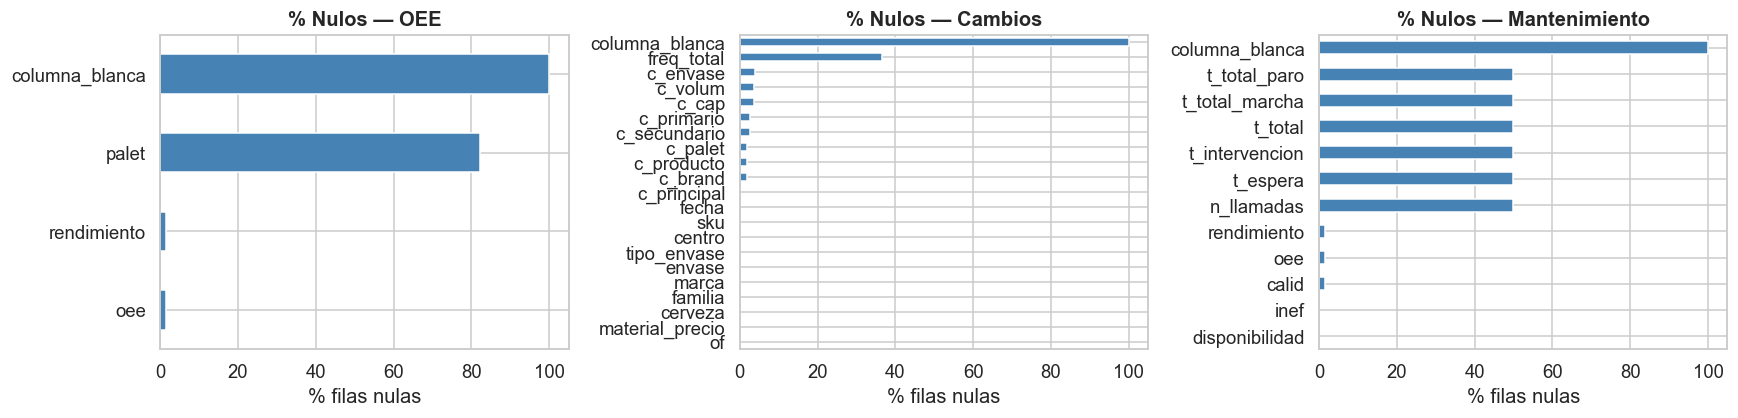


Cobertura OEE por línea:
      count   mean    std    min    max
tren                                   
14      420  0.422  0.131  0.012  0.812
17      915  0.531  0.150  0.002  1.573
19      774  0.481  0.168  0.001  0.923


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
datasets = {'OEE': df_oee, 'Cambios': df_cam, 'Mantenimiento': df_mant}

for ax, (name, df) in zip(axes, datasets.items()):
    pct_null = df.isnull().mean() * 100
    pct_null = pct_null[pct_null > 0].sort_values(ascending=True)
    if pct_null.empty:
        ax.text(0.5, 0.5, 'Sin valores nulos', ha='center', va='center')
    else:
        pct_null.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'% Nulos — {name}', fontweight='bold')
    ax.set_xlabel('% filas nulas')

plt.tight_layout()
plt.show()

# Resumen de cobertura OEE
print("\nCobertura OEE por línea:")
print(df_oee.groupby('tren')['oee'].agg(['count', 'mean', 'std', 'min', 'max']).round(3))

## 3 · Estacionalidad: OEE y volumen por mes y línea

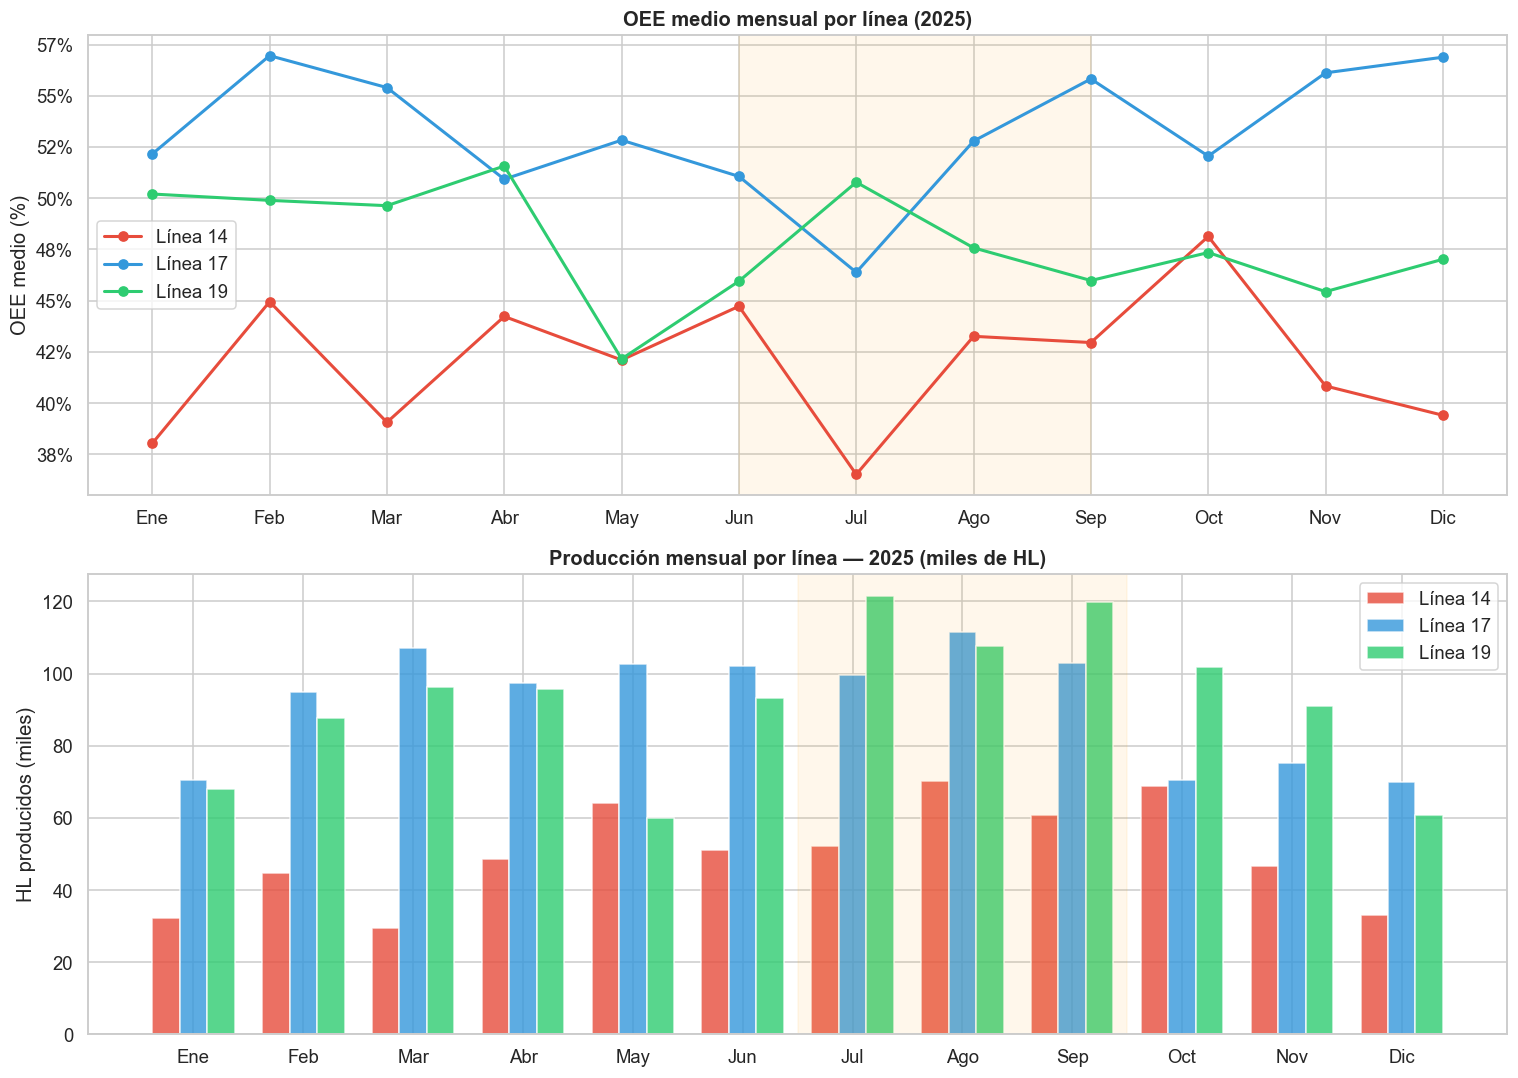

Insight: La temporada alta (Jul-Sep) produce ~75% más HL que Dic-Ene.
         El OEE es LIGERAMENTE PEOR en temporada alta → más cambios, más presión.


In [4]:
df_oee['mes'] = df_oee['fecha'].dt.month
df_vol['mes']  = df_vol['fecha'].dt.month

months_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# OEE por mes y línea
for line, color in zip(['14','17','19'], ['#e74c3c','#3498db','#2ecc71']):
    monthly = (
        df_oee[df_oee['tren'] == line]
        .groupby('mes')['oee'].mean()
    )
    ax1.plot(monthly.index, monthly.values * 100, marker='o', label=f'Línea {line}', color=color, lw=2)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months_es)
ax1.set_ylabel('OEE medio (%)')
ax1.set_title('OEE medio mensual por línea (2025)', fontweight='bold')
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax1.axvspan(6, 9, alpha=0.08, color='orange', label='Temporada alta')

# Volumen HL por mes y línea
for line, color in zip(['14','17','19'], ['#e74c3c','#3498db','#2ecc71']):
    monthly_hl = (
        df_vol[df_vol['tren'] == line]
        .groupby('mes')['hl'].sum() / 1000
    )
    ax2.bar(
        [m + (['14','17','19'].index(line) - 1) * 0.25 for m in monthly_hl.index],
        monthly_hl.values, width=0.25, label=f'Línea {line}', color=color, alpha=0.8
    )

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(months_es)
ax2.set_ylabel('HL producidos (miles)')
ax2.set_title('Producción mensual por línea — 2025 (miles de HL)', fontweight='bold')
ax2.legend()
ax2.axvspan(6.5, 9.5, alpha=0.08, color='orange')

plt.tight_layout()
plt.show()

print("Insight: La temporada alta (Jul-Sep) produce ~75% más HL que Dic-Ene.")
print("         El OEE es LIGERAMENTE PEOR en temporada alta → más cambios, más presión.")

## 4 · Throughput por línea y SKU

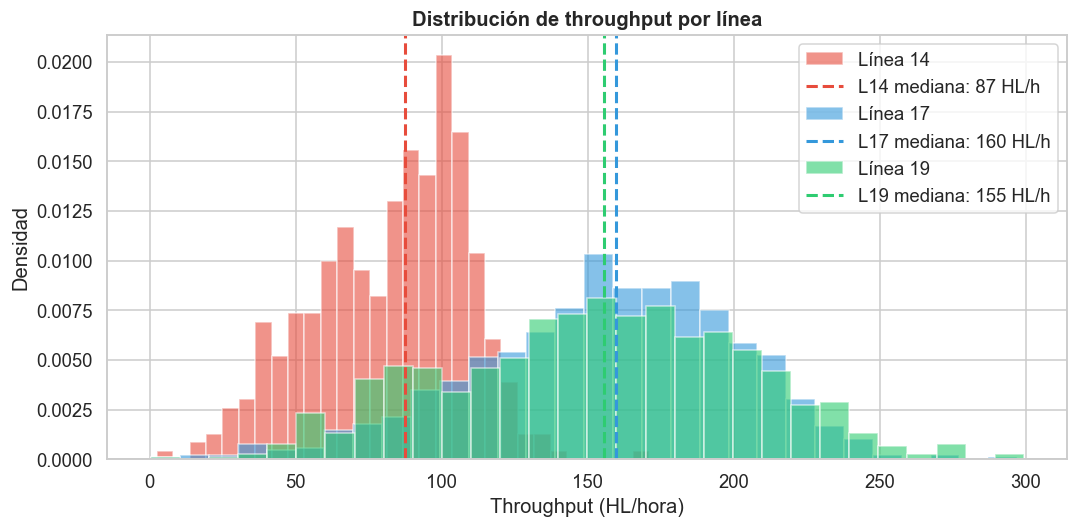

Throughput mediano por línea:
tren
14     87.3
17    159.6
19    155.4

⚠ Línea 14 es ~2x más lenta que L17/L19 — asignarle el mismo volumen cuesta el doble de tiempo.


In [5]:
# Unir volumen con tiempo para calcular HL/hora
df_tiem_agg = df_tiem.groupby('of')['h_tot'].sum().reset_index().rename(columns={'h_tot': 'h_tot_of'})
df_thru = df_vol.merge(df_tiem_agg, on='of', how='left')
df_thru = df_thru[(df_thru['h_tot_of'] > 0) & (df_thru['hl'] > 0)].copy()
df_thru['hl_per_h'] = df_thru['hl'] / df_thru['h_tot_of']

fig, ax = plt.subplots(figsize=(10, 5))
for line, color in zip(['14','17','19'], ['#e74c3c','#3498db','#2ecc71']):
    data = df_thru[df_thru['tren'] == line]['hl_per_h'].dropna()
    ax.hist(data, bins=30, alpha=0.6, color=color, label=f'Línea {line}', density=True)
    ax.axvline(data.median(), color=color, linestyle='--', lw=2, label=f'L{line} mediana: {data.median():.0f} HL/h')

ax.set_xlabel('Throughput (HL/hora)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de throughput por línea', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("Throughput mediano por línea:")
print(df_thru.groupby('tren')['hl_per_h'].median().round(1).to_string())
print("\n⚠ Línea 14 es ~2x más lenta que L17/L19 — asignarle el mismo volumen cuesta el doble de tiempo.")

## 5 · Distribución de tipos de cambio

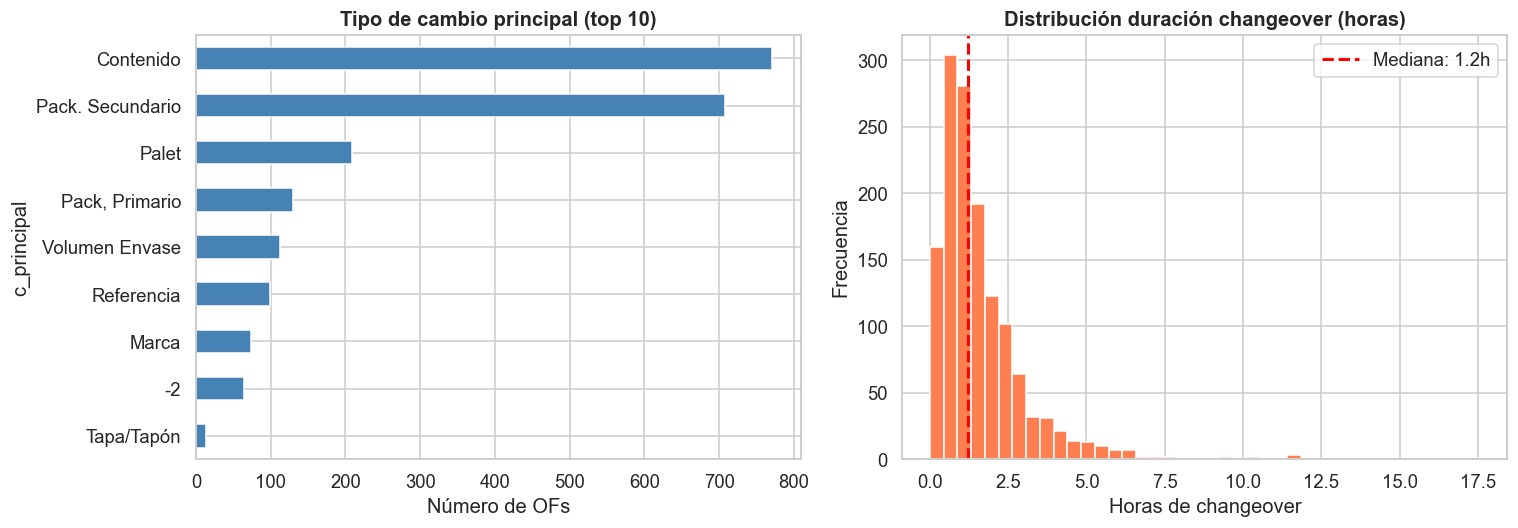

Changeovers con duración registrada: 1381 / 2181 (63.3%)
Duración media: 1.65h | Máxima: 17.6h


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tipo de cambio principal
tipo_counts = df_cam['c_principal'].value_counts().head(10)
tipo_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Tipo de cambio principal (top 10)', fontweight='bold')
axes[0].set_xlabel('Número de OFs')
axes[0].invert_yaxis()

# Duración del changeover (freq_total)
freq_valid = df_cam[df_cam['freq_total'].notna() & (df_cam['freq_total'] > 0)]['freq_total']
axes[1].hist(freq_valid, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribución duración changeover (horas)', fontweight='bold')
axes[1].set_xlabel('Horas de changeover')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(freq_valid.median(), color='red', lw=2, linestyle='--',
                label=f'Mediana: {freq_valid.median():.1f}h')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Changeovers con duración registrada: {df_cam['freq_total'].notna().sum()} / {len(df_cam)} ({df_cam['freq_total'].notna().mean():.1%})")
print(f"Duración media: {freq_valid.mean():.2f}h | Máxima: {freq_valid.max():.1f}h")

## 6 · Carga y análisis del Diario de planificación (semana test: 18-24 mayo 2026)

In [7]:
df_diario = load_diario_hl(DATA_DIR / 'Diario Hl_Planif.xlsx')

assert not df_diario['sku'].str.lower().str.contains('total', na=False).any(), \
    "El Diario contiene filas TOTAL mal parseadas como SKU"

print(f"Diario cargado: {len(df_diario)} registros")
print(f"Semana: {df_diario['fecha'].min().date()} -> {df_diario['fecha'].max().date()}")
print(f"Lineas: {sorted(df_diario['tren'].unique())} | SKUs unicos: {df_diario['sku'].nunique()}")
print(f"HL total semana: {df_diario['hl_planificado'].sum():,.1f}")
print(f"\nHL total por linea:")
print(df_diario.groupby('tren')['hl_planificado'].sum().round(1).to_string())
print()
df_diario.head(12)

Diario cargado: 39 registros
Semana: 2026-05-18 -> 2026-05-21
Lineas: ['14', '17', '19'] | SKUs unicos: 33
HL total semana: 36,933.5

HL total por linea:
tren
14     7440.8
17    14390.6
19    15102.0



,fecha,tren,sku,hl_planificado,hl_acordado,row_order
0,2026-05-18,14,ED13LMCM,475.200012,475.200012,0
1,2026-05-18,14,ED13LTMC,253.440002,253.440002,1
2,2026-05-18,14,FDT13LT,1433.520020,1433.520020,5
3,2026-05-18,14,FDT13LTM,237.600006,237.600006,6
4,2026-05-19,14,ED13LTNN,1663.199951,1663.199951,2
5,2026-05-20,14,ED13LTNN,2328.479980,2328.479980,3
6,2026-05-21,14,ED13LTNN,475.200012,1247.399902,4
7,2026-05-21,14,VO13LTMP,574.200012,0.000000,7
8,2026-05-18,17,ED13P24N,396.000000,396.000000,9
9,2026-05-18,17,FD13LTNN,843.239990,843.239990,10


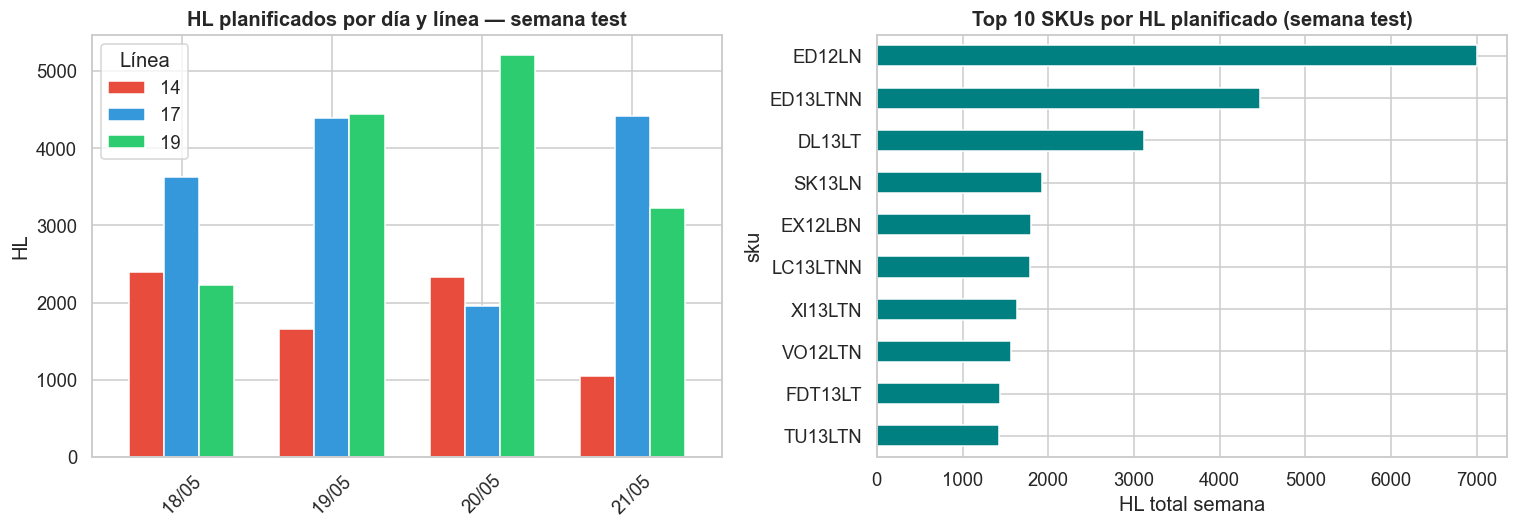


Resumen semana test:
          HL_total
tren              
14     7440.839996
17    14390.640030
19    15102.000015


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HL planificado por línea y día
pivot = df_diario.pivot_table(index='fecha', columns='tren', values='hl_planificado', aggfunc='sum')
pivot.plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db','#2ecc71'], width=0.7)
axes[0].set_title('HL planificados por día y línea — semana test', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels([d.strftime('%d/%m') for d in pivot.index], rotation=45)
axes[0].set_ylabel('HL')
axes[0].legend(title='Línea')

# Top SKUs por HL total en la semana
sku_total = df_diario.groupby('sku')['hl_planificado'].sum().sort_values(ascending=False).head(10)
sku_total.plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 10 SKUs por HL planificado (semana test)', fontweight='bold')
axes[1].set_xlabel('HL total semana')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nResumen semana test:")
print(df_diario.groupby('tren')['hl_planificado'].sum().rename('HL_total').to_frame())

## 7 · Matriz OEE por SKU y Línea (top SKUs)

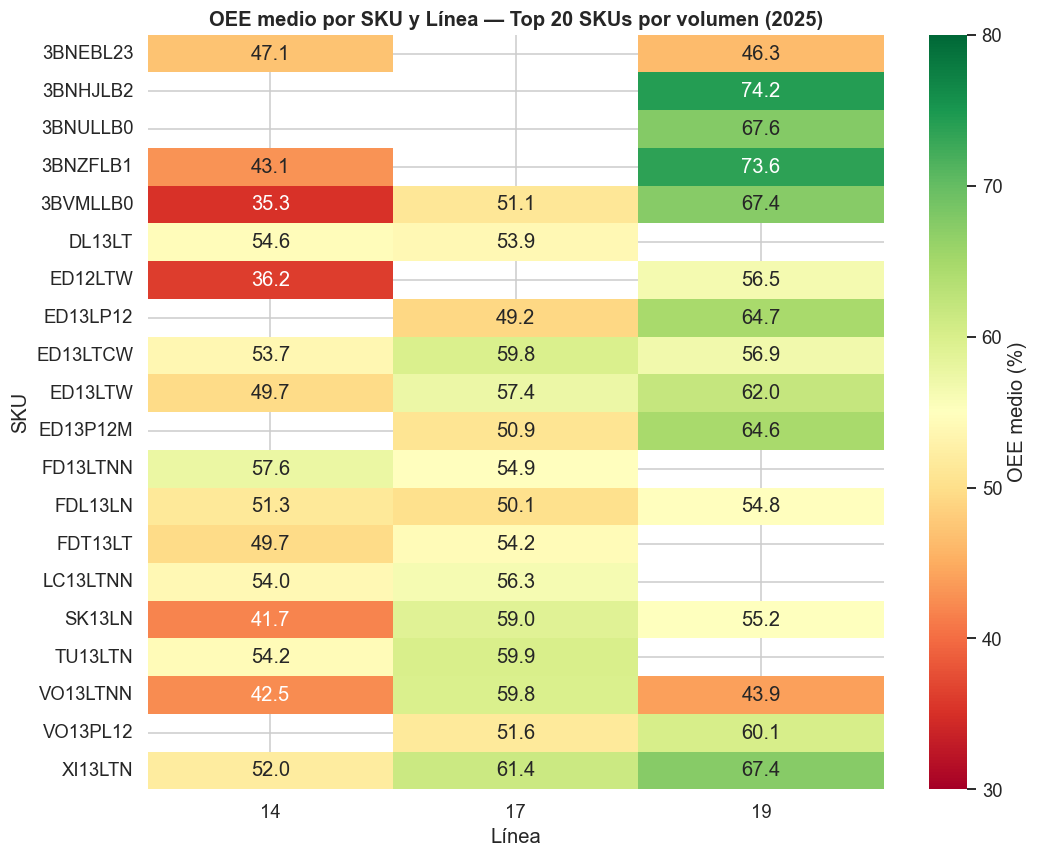


Insight: Cada SKU tiene una 'línea óptima'. Asignar un SKU a su línea óptima
         puede suponer entre 5 y 20 puntos de OEE de diferencia.


In [9]:
top_skus = (
    df_vol.groupby('sku')['hl'].sum()
    .sort_values(ascending=False)
    .head(20).index.tolist()
)

oee_matrix = (
    df_oee[df_oee['sku'].isin(top_skus)]
    .groupby(['sku', 'tren'])['oee']
    .mean()
    .unstack('tren')
    .reindex(columns=['14', '17', '19'])
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    oee_matrix * 100, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=30, vmax=80, ax=ax,
    cbar_kws={'label': 'OEE medio (%)'}
)
ax.set_title('OEE medio por SKU y Línea — Top 20 SKUs por volumen (2025)', fontweight='bold')
ax.set_xlabel('Línea')
ax.set_ylabel('SKU')
plt.tight_layout()
plt.show()

print("\nInsight: Cada SKU tiene una 'línea óptima'. Asignar un SKU a su línea óptima")
print("         puede suponer entre 5 y 20 puntos de OEE de diferencia.")

## 8 · Síntesis de hallazgos EDA

In [10]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║           SÍNTESIS DE HALLAZGOS EDA — LineWise 2025            ║
╠══════════════════════════════════════════════════════════════════╣
║ 1. ESTACIONALIDAD                                               ║
║    • Pico productivo: Jul-Sep (+75% HL vs. Dic-Ene)            ║
║    • OEE ligeramente PEOR en verano (más cambios, más presión) ║
║    → Optimizar secuencias es MÁS valioso en temporada alta     ║
║                                                                  ║
║ 2. THROUGHPUT ASIMÉTRICO                                        ║
║    • L14: ~90 HL/h  |  L17: ~170 HL/h  |  L19: ~175 HL/h     ║
║    → Asignar el mismo volumen a L14 cuesta el doble de tiempo  ║
║                                                                  ║
║ 3. CAMBIOS DE FORMATO                                           ║
║    • Tipo más frecuente: Contenido (cerveza) — 771 casos       ║
║    • Tipo más costoso: Volumen Envase (hasta 8h en L17)        ║
║    • 63% de OFs tienen duración de changeover registrada       ║
║                                                                  ║
║ 4. OEE POR SKU-LÍNEA                                           ║
║    • Diferencias de hasta 20pp entre la mejor y peor línea    ║
║    • La asignación correcta SKU → Línea es el primer lever     ║
║                                                                  ║
║ 5. SEMANA TEST (18-24 mayo 2026)                               ║
║    • L17 y L19 concentran la mayoría del volumen               ║
║    • L14 tiene carga menor → más flexibilidad de reordenación  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║           SÍNTESIS DE HALLAZGOS EDA — LineWise 2025            ║
╠══════════════════════════════════════════════════════════════════╣
║ 1. ESTACIONALIDAD                                               ║
║    • Pico productivo: Jul-Sep (+75% HL vs. Dic-Ene)            ║
║    • OEE ligeramente PEOR en verano (más cambios, más presión) ║
║    → Optimizar secuencias es MÁS valioso en temporada alta     ║
║                                                                  ║
║ 2. THROUGHPUT ASIMÉTRICO                                        ║
║    • L14: ~90 HL/h  |  L17: ~170 HL/h  |  L19: ~175 HL/h     ║
║    → Asignar el mismo volumen a L14 cuesta el doble de tiempo  ║
║                                                                  ║
║ 3. CAMBIOS DE FORMATO                                           ║
║    • Tipo más frecuente: Contenido (cerveza) — 771 casos       ║
║    • Tipo más costoso: Volumen Envase (hasta 8h en

## 5 · Red de Similitud de SKUs (Modelo de Grafo Sofisticado)

Como paso previo al modelo de transición avanzado, definimos una **Red de Similitud de SKUs** basada en características compartidas (formato, marca, envase, unidades/caja). Esto nos permite propagar costes en el grafo incluso para transiciones nunca vistas en el histórico de 2025.

In [ ]:
from analisis_postmorten.sophisticated_graph import SophisticatedGraphModel

# Inicializar el modelo con los datos históricos de 2025
sg_model = SophisticatedGraphModel(df_oee=dfs['oee'])

# Extraer características de una muestra de SKUs históricos
all_skus = dfs['oee']['sku'].dropna().unique().tolist()[:20]
G_sim = sg_model.build_similarity_graph(all_skus, threshold=0.15)

print(f"Grafo de similitud de SKUs: {G_sim.number_of_nodes()} nodos | {G_sim.number_of_edges()} aristas")

# Visualizar una porción de la red de similitud
import networkx as nx
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sim, k=0.5, seed=42)
nx.draw_networkx_nodes(G_sim, pos, node_size=300, node_color='lightblue')
nx.draw_networkx_labels(G_sim, pos, font_size=8, font_weight='bold')
weights = [d['weight'] * 3 for u, v, d in G_sim.edges(data=True)]
nx.draw_networkx_edges(G_sim, pos, width=weights, edge_color='gray', alpha=0.6)
plt.title('Red de Similitud de SKUs (Muestra 2025)', fontweight='bold')
plt.axis('off')
plt.show()